In [ ]:
import sys
sys.path.insert(0, '../lib/')

In [ ]:
import collections
import functools
import os
import pathlib

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.stats.multitest
import joblib

import common_data

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pd.options.display.max_columns = 200
pd.options.display.max_rows = 200
%config InlineBackend.figure_format = "retina"

In [ ]:
BASE = common_data.DATA / '05_pseudobulk/10_vap_cured'

In [ ]:
adata = sc.read_h5ad(common_data.SC_NORM)

In [5]:
groups = pd.read_csv(BASE / '_group_labels.csv', index_col=0)

Select genes that are detected (count > 0) in at least 80% of samples
in at least one comparison group

In [6]:
%%time
PSEUDOBULK_CELLS = 50
PSEUDOBULK_EXPR_IN_GROUP = 0.8
genes_to_keep = {}
for ct in adata.obs.Level_6.unique():
    genes = None
    for group in groups.group.unique():
        samples = groups.bal_barcode[groups.group.eq(group)]
        pseudobulks = []
        for sample in samples:
            idx = adata.obs.Level_6.eq(ct) & adata.obs.bal_barcode.eq(sample)
            if idx.sum() < PSEUDOBULK_CELLS:
                continue
            pseudobulks.append(adata.raw.X[idx, :].sum(axis=0).A1)
        if len(pseudobulks) == 0:
            continue
        pseudobulks = pd.DataFrame(pseudobulks, columns=adata.raw.var_names)
        expr_frac = (pseudobulks > 0).sum(axis=0) / pseudobulks.shape[0]
        group_genes = pseudobulks.columns[expr_frac.ge(PSEUDOBULK_EXPR_IN_GROUP)]
        if genes is None:
            genes = group_genes.to_numpy()
        else:
            genes = np.union1d(genes, group_genes)
    genes_to_keep[ct] = genes

CPU times: user 11.7 s, sys: 274 ms, total: 12 s
Wall time: 12 s


In [7]:
{k: len(v) for k, v in genes_to_keep.items() if v is not None}

{'CD4 T cells': 10324,
 'CD8 T cells': 11144,
 'NUPR1+ Macs': 12650,
 'B cells': 9039,
 'MRC1+C1QA+': 11558,
 'DC2': 10608,
 'MRC1+C1QA-': 11834,
 'Proliferating CD4 T cells': 10281,
 'Proliferating CD8 T cells': 9712,
 'Classical monocytes-2 IL1B': 10209,
 'Secretory cells': 12545,
 'Proliferating NUPR1+ Macs': 11948,
 'Tregs': 9445,
 'Ciliated cells': 12037,
 'gdT cells': 9318,
 'Migratory DC': 6739,
 'Interstitial macrophages': 9465,
 'Classical monocytes-1 CCR2': 8939,
 'AT1 and AT2': 15655,
 'Proliferating plasma cells': 10361,
 'Non-classical monocytes': 13236,
 'Plasma cells': 9564}

In [12]:
genes_to_keep['Perivascular macrophages'] = genes_to_keep['Interstitial macrophages']

In [ ]:
PADJ_CUTOFF = 0.05
class ComparisonInfo:
    def __init__(self, control, condition, genes, genes_to_keep):
        self.control = control
        self.condition = condition
        self.genes_raw = genes
        self.filter_genes(genes_to_keep)

    def filter_genes(self, genes_to_keep):
        filtered_degs = self.genes_raw.loc[self.genes_raw.index.isin(genes_to_keep), :].copy()
        filtered_degs = filtered_degs.loc[filtered_degs.padj.notna()].copy()
        # recompute FDR correction on the filtered genes:
        filtered_degs['padj'] = statsmodels.stats.multitest.fdrcorrection(
            filtered_degs.pvalue,
            alpha=PADJ_CUTOFF
        )[1]
        # recompute gene status based on new `padj`
        filtered_degs['sign'] = ''
        filtered_degs.loc[
            filtered_degs.padj.lt(PADJ_CUTOFF)
            & filtered_degs.log2FoldChange.gt(0),
            'sign'
        ] = f'Up in {self.condition}'
        filtered_degs.loc[
            filtered_degs.padj.lt(PADJ_CUTOFF)
            & filtered_degs.log2FoldChange.lt(0),
            'sign'
        ] = f'Up in {self.control}'
        self.genes = filtered_degs


class CellTypeInfo:
    def __init__(self, path, genes_to_keep):
        self.path = path
        self.comparisons = []
        self.meta = pd.read_csv(path / 'meta.csv', index_col=0)
        self.name = self.meta.cell_type.values[0]

        self.load_comparisons(genes_to_keep)

    def load_comparisons(self, genes_to_keep):
        for run in self.path.glob('**/degs.csv'):
            self.comparisons.append(
                ComparisonInfo(
                    'vap_is_cured_0',
                    'vap_is_cured_1',
                    pd.read_csv(run, index_col=0),
                    genes_to_keep[self.name]
                )
            )

    @property
    def n_comparisons(self):
        return len(self.comparisons)

In [9]:
class TaskInfo:
    def __init__(self, task):
        self.task = task
        self.info = {}

In [13]:
%%time
data = {}
task = 'vap_cured'
task_info = TaskInfo(task)
for cell_type_path in sorted(BASE.iterdir()):
    if cell_type_path.name.startswith('.') or cell_type_path.name.startswith('_'):
        continue
    if not cell_type_path.is_dir():
        continue
    if not (cell_type_path / 'meta.csv').exists():
        continue
    info = CellTypeInfo(cell_type_path, genes_to_keep)
    if info.n_comparisons > 0:
        task_info.info[cell_type_path.name] = info
if len(task_info.info) > 0:
    data[task] = task_info

CPU times: user 298 ms, sys: 10.3 ms, total: 309 ms
Wall time: 581 ms


In [14]:
data['vap_cured'].info

{'CD4_T_cells': <__main__.CellTypeInfo at 0x152af0fea800>,
 'CD8_T_cells': <__main__.CellTypeInfo at 0x152c28d6fc10>,
 'Ciliated_cells': <__main__.CellTypeInfo at 0x152af0fea830>,
 'Classical_monocytes-1_CCR2': <__main__.CellTypeInfo at 0x152af0d976d0>,
 'Classical_monocytes-2_IL1B': <__main__.CellTypeInfo at 0x152af0d97790>,
 'DC2': <__main__.CellTypeInfo at 0x152af0dda350>,
 'MRC1+C1QA+': <__main__.CellTypeInfo at 0x152af0dd9cf0>,
 'MRC1+C1QA-': <__main__.CellTypeInfo at 0x152af0dd9f90>,
 'NUPR1+_Macs': <__main__.CellTypeInfo at 0x152af0dd8910>,
 'Perivascular_macrophages': <__main__.CellTypeInfo at 0x15290d2c8040>,
 'Plasma_cells': <__main__.CellTypeInfo at 0x15290d2cfdf0>,
 'Proliferating_CD4_T_cells': <__main__.CellTypeInfo at 0x15290d2cc370>,
 'Proliferating_CD8_T_cells': <__main__.CellTypeInfo at 0x15290d04fa30>,
 'Proliferating_NUPR1+_Macs': <__main__.CellTypeInfo at 0x15290d2d1bd0>,
 'Proliferating_plasma_cells': <__main__.CellTypeInfo at 0x15290d2c0b50>,
 'Secretory_cells': <

In [ ]:
joblib.dump(data, '12_deg_data.joblib')

['32_deg_data.joblib']

In [ ]:
BASE = common_data.DATA / '05_pseudobulk/12_degs'
for _, task in data.items():
    for k, ct_info in task.info.items():
        comp = ct_info.comparisons[0]
        deg_path = BASE / task.task / k / 'degs.csv'
        if deg_path.exists():
            print(f'File {deg_path} already exists, skipping')
            continue
        # Threshold GSEA analysis to at least 1000 genes in comparison
        if comp.genes.shape[0] < 1000:
            continue
        ct_path = BASE / task.task / k
        os.makedirs(ct_path, exist_ok=True)
        comp.genes.sort_values('log2FoldChange').to_csv(deg_path)

In [17]:
n_degs_plot = pd.DataFrame()
n_degs = pd.DataFrame()
for task in data.values():
    for ct in task.info.values():
        name = ct.name
        n_genes = ct.comparisons[0].genes.padj.lt(0.05).sum()
        n_degs.loc[task.task, name] = n_genes
        if n_genes > 0:
            n_genes = np.log10(n_genes)
        n_degs_plot.loc[task.task, name] = n_genes
n_degs = n_degs.T.sort_index()
n_degs_plot = n_degs_plot.T.sort_index()

Text(0.5, 1.0, 'VAP is cured number of DEGs')

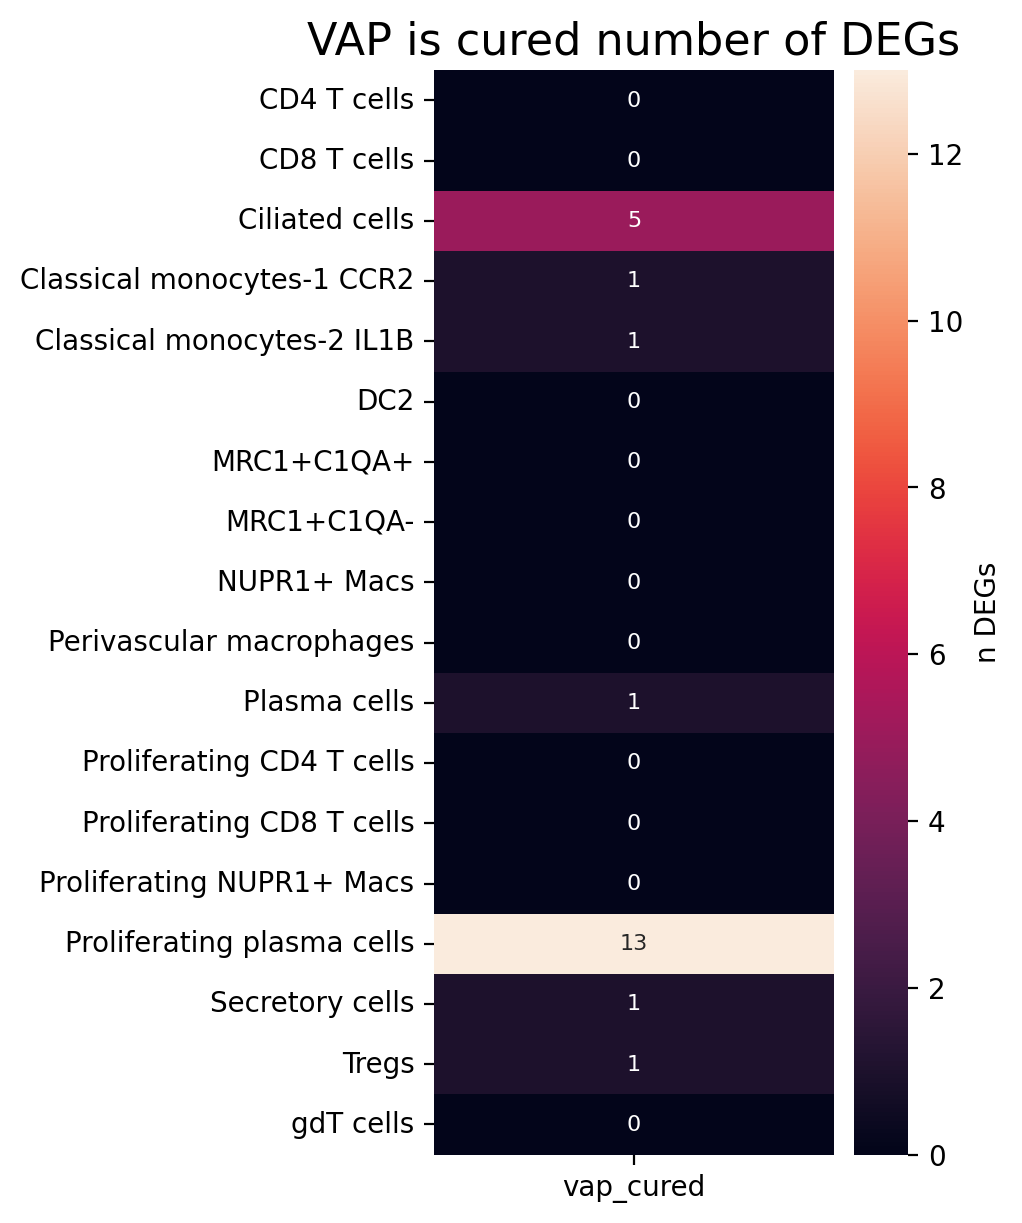

In [18]:
fig, ax = plt.subplots(figsize=(5, 6), constrained_layout=True)
sns.heatmap(
    n_degs,
    cbar_kws=dict(
        label='n DEGs'
    ),
    annot=n_degs,
    fmt='.0f',
    annot_kws=dict(
        size=8
    ),
    ax=ax
)
ax.set_title('VAP is cured number of DEGs', size=16)

**NB**: Negative is VAP not cured (class 0), positive is VAP cured (class 1)

In [21]:
task = 'vap_cured'
cell_type = 'Proliferating_plasma_cells'
print(f'DEGs in {cell_type} for {task}')
df = data[task].info[cell_type].comparisons[0].genes
df = df.loc[df.sign.ne('')].sort_values('log2FoldChange')
pd.concat([df.head(6), df.tail(6)])

DEGs in Proliferating_plasma_cells for vap_cured


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,sign
IGLL5,3109.636764,-3.281502,0.530325,-6.187716,6.104212e-10,0.000006,Up in vap_is_cured_0
CCND2,1748.722897,-1.120440,0.268652,-4.170597,3.038025e-05,0.031334,Up in vap_is_cured_0
SLC43A3,98.658692,-1.088834,0.258775,-4.207639,2.580527e-05,0.031334,Up in vap_is_cured_0
IL6R,123.228836,-0.981629,0.240721,-4.077873,4.544963e-05,0.038628,Up in vap_is_cured_0
HNRNPAB,552.272463,-0.722813,0.174249,-4.148159,3.351598e-05,0.031334,Up in vap_is_cured_0
SRSF8,54.742502,0.854221,0.214518,3.982048,6.832403e-05,0.049135,Up in vap_is_cured_1
GNPTAB,74.125567,1.040472,0.231988,4.485026,7.290505e-06,0.022720,Up in vap_is_cured_1
DPP7,161.512431,1.071555,0.245192,4.370277,1.240893e-05,0.023202,Up in vap_is_cured_1
IGLC2,6198.522234,2.427651,0.549108,4.421078,9.820980e-06,0.022954,Up in vap_is_cured_1
CXCL10,10.984077,5.621069,1.353138,4.154100,3.265702e-05,0.031334,Up in vap_is_cured_1


In [22]:
cell_type = 'Ciliated_cells'
print(f'DEGs in {cell_type} for {task}')
df = data[task].info[cell_type].comparisons[0].genes
df = df.loc[df.sign.ne('')].sort_values('log2FoldChange')
pd.concat([df.head(2), df.tail(3)])

DEGs in Ciliated_cells for vap_cured


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,sign
ALOX15,294.875716,-1.638015,0.377113,-4.343567,1.401874e-05,4.070692e-02,Up in vap_is_cured_0
CHST9,498.495788,-0.990637,0.202875,-4.882999,1.044843e-06,6.067927e-03,Up in vap_is_cured_0
RAB36,124.618306,0.642462,0.151186,4.249480,2.142671e-05,4.977425e-02,Up in vap_is_cured_1
CRISPLD1,19.428015,1.179344,0.262552,4.491848,7.060791e-06,2.733703e-02,Up in vap_is_cured_1
MTRNR2L8,152.022125,5.655142,0.789778,7.160418,8.043137e-13,9.342104e-09,Up in vap_is_cured_1
